In [1]:
import numpy as np
import pandas as pd 
import os
from utils import survival_km_stats,fit_cox_loo_oof_penalized
from joblib import Parallel, delayed
from lifelines.utils import concordance_index
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from lifelines import CoxPHFitter
from scipy.stats import chi2


font_path = "/scratch/individuals/yujie/font.ttf"
fm.fontManager.addfont(font_path)
# get the exact family name from the font file
font_name = fm.FontProperties(fname=font_path).get_name()
print("Using:", font_name)
plt.rcParams.update({
    "font.family": font_name,
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,

    # Set ALL linewidths to 1.0
    "lines.linewidth": 1.4,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "ytick.major.size": 1.5,
    "xtick.major.size": 1.5,
    "grid.linewidth": 0.8,
    "axes.titlepad": 0.5,
    "axes.labelpad": 1,
    "savefig.pad_inches": 0.1
})

OUTDIR = "../result/prognostic_evaluation/"
#os.makedirs(OUTDIR, exist_ok=True)
N_JOBS_DATASETS = 5

# -------------------------
# Load data
# -------------------------
metadata = pd.read_csv("./data/metadata.csv", index_col=0)
nuclei_feature_unique = pd.read_csv("./data/nuclei_feature.csv", index_col=0)
glandular_feat_unique = pd.read_csv("./data/gland_feature.csv", index_col=0)
graph_feature = pd.read_csv("./data/Scale3D_feature.csv",index_col=0)

combined_nuclei_gland = pd.concat([nuclei_feature_unique, glandular_feat_unique], axis=1)
combined_x = pd.concat([nuclei_feature_unique, glandular_feat_unique, graph_feature], axis=1)

# Sanity checks
assert metadata.index.equals(nuclei_feature_unique.index)
assert metadata.index.equals(glandular_feat_unique.index)
assert metadata.index.equals(graph_feature.index)
assert metadata.index.equals(combined_nuclei_gland.index)
assert metadata.index.equals(combined_x.index)

y = metadata["5yBCR"]

penalizer_grid = np.logspace(-3, 2, 21) 

def loo_cox_regression_validation(X,metadata,k=20,inner_splits= 4,penalizer_grid=penalizer_grid):
    df = X.copy()
    df = df.loc[metadata.index]
    df["event"] = metadata["recurrence"]
    df["time"]  = metadata["days_to_event"]
    df["5yrBCR"] = metadata["5yBCR"]
    cox_res = fit_cox_loo_oof_penalized(df,k=k,inner_splits=inner_splits ,penalizer_grid=penalizer_grid)
   
    result_df = cox_res["df_aligned"]
    result_df["y_probs"] = cox_res["oof_risk"]
    c_index_oof = concordance_index(result_df["time"].values, -result_df["y_probs"].values, result_df["event"].values)
    c_text = f"C-index = {c_index_oof:.2f}"
    cutoff = cox_res["median"]

    high, low, p_text,hr_text = survival_km_stats(result_df,cutoff)
    print(f"C_index{c_text};pvalue{p_text};HR{hr_text}")
    return {
        "cox_res": cox_res,
        "high": high,
        "low": low,
        "p_text": p_text,
        "hr_text": hr_text,
        "c_text": c_text}



def run_one(name: str, X: pd.DataFrame, out_path: str):
    res = loo_cox_regression_validation(
        X,
        metadata,k=20)
    np.savez(out_path, res)
    return name, out_path,res

jobs = [
    ("nuclei", nuclei_feature_unique, os.path.join(OUTDIR, "nuclei_res.npz")),
    ("gland", glandular_feat_unique, os.path.join(OUTDIR, "gland_res.npz")),
    ("nuclei_gland", combined_nuclei_gland, os.path.join(OUTDIR, "combine_nuclei_gland_res.npz")),
    ("scale3d", graph_feature, os.path.join(OUTDIR, "scale3d_res.npz")),
    ("all", combined_x, os.path.join(OUTDIR, "combine_res_d40.npz")),
]



Using: Arial Unicode MS


In [2]:
# -------------------------
# Run in parallel
# -------------------------
results = Parallel(n_jobs=N_JOBS_DATASETS, backend="loky", verbose=10)(
    delayed(run_one)(name, X, out_path)
    for name, X, out_path in jobs
)

res_dict = {name: res for name, out_path, res in results}
nuclei_res = res_dict["nuclei"]
gland_res = res_dict["gland"]
nuclei_gland_res = res_dict["nuclei_gland"]
scale3d_res = res_dict["scale3d"]
all_res = res_dict["all"]

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.


C_indexC-index = 0.62;pvaluep = 0.0227;HRHR = 2.33 (1.10 – 4.93)
C_indexC-index = 0.66;pvaluep = 0.00443;HRHR = 2.77 (1.33 – 5.77)


[Parallel(n_jobs=5)]: Done   2 out of   5 | elapsed:  2.9min remaining:  4.4min


C_indexC-index = 0.64;pvaluep = 0.0131;HRHR = 2.65 (1.19 – 5.92)


[Parallel(n_jobs=5)]: Done   3 out of   5 | elapsed:  3.7min remaining:  2.5min


C_indexC-index = 0.65;pvaluep = 0.00288;HRHR = 2.90 (1.39 – 6.04)
C_indexC-index = 0.71;pvaluep < 0.001;HRHR = 4.29 (1.85 – 9.94)


[Parallel(n_jobs=5)]: Done   5 out of   5 | elapsed:  5.7min finished


In [3]:

def plot_km(combine_res,name,color,yrange,xlabel=False):    
    high, low, p_text,hr_text,c_text = combine_res["high"],combine_res["low"],combine_res["p_text"],combine_res["hr_text"],combine_res["c_text"],


    fig, ax = plt.subplots(figsize=(2.5, yrange))
    kmf_high = KaplanMeierFitter()
    kmf_low = KaplanMeierFitter()

    kmf_high.fit(high["time"]/30, high["event"], label="High Risk")
    kmf_low.fit(low["time"]/30, low["event"], label="Low Risk")

    # Plot with styling
    kmf_high.plot(ci_show=False, color=color, linestyle="--")
    kmf_low.plot(ci_show=False, color=color, linestyle="-")
    # Formatting (matches your example)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.3),  # move legend above plot
        ncol=2,
        frameon=False,
        handlelength=2)
    if xlabel:
        ax.set_xticks([0,30,60])
        ax.set_xlim(0, 70)
        plt.xlabel("Time (months)")
    else:
        ax.set_xlabel(None)
        ax.set_xticks([])

    plt.ylim(0, 1.0)
    # Draw annotation text
    plt.text(1, 0.03, f"{p_text}\n{hr_text}\n{c_text}",
            ha="left", va="bottom")
    
    ax.set_yticks([0,0.5,1])
    ax.set_ylim(0, 1)
    plt.tight_layout()
    #plt.savefig(f"../figures/cox_{name}_months.pdf", bbox_inches="tight")
    plt.show()

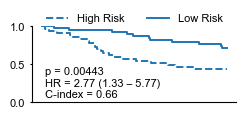

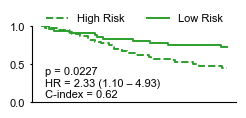

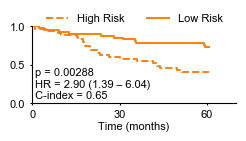

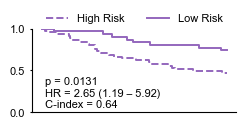

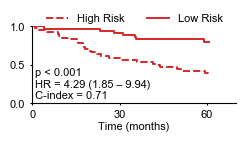

In [4]:
plot_km(nuclei_res,"nuclei","C0",1.3,xlabel=False)
plot_km(gland_res,"gland","C2",1.3,xlabel=False)
plot_km(scale3d_res,"scale3d","C1",1.6,xlabel=True)
plot_km(nuclei_gland_res,"nuclei+gland","C4",1.4,xlabel=False)
plot_km(all_res,"nuclei+gland+scale3d","C3",1.6,xlabel=True)


In [5]:
df_eval = nuclei_gland_res["cox_res"]["df_aligned"]
df_eval["score_GN"]  = nuclei_gland_res["cox_res"]["oof_risk"].values
df_eval["score_GNG"] = scale3d_res["cox_res"]["oof_risk"].values

# reduced
cph_r = CoxPHFitter().fit(
    df_eval[["time", "event", "score_GN"]],
    duration_col="time", event_col="event"
)

# full
cph_f = CoxPHFitter().fit(
    df_eval[["time", "event", "score_GN", "score_GNG"]],
    duration_col="time", event_col="event"
)

# Likelihood-ratio test
lrt = 2 * (cph_f.log_likelihood_ - cph_r.log_likelihood_)
df_lrt = cph_f.params_.shape[0] - cph_r.params_.shape[0]
p_lrt = chi2.sf(lrt, df=df_lrt)

n_patients = df_eval.shape[0]
n_events = int(df_eval["event"].sum())
print(f"LRT: chi-square({df_lrt}) = {lrt:.3f}, p = {p_lrt:.4g}")

LRT: chi-square(1) = 8.468, p = 0.003614
